In [1]:
from typing import TypedDict 
from langgraph.graph import StateGraph , START , END

In [2]:
class AgentState(TypedDict):
    name : str
    number : int
    result : str

In [3]:
def greeting(state : AgentState)  -> AgentState :
    """this is a greetingn message"""
    state['result'] =  f"Hi {state['name']},  Your number {state['number']} is "
    return state

In [4]:
def even_node(state: AgentState) -> AgentState:
    state["result"] = state["result"] + "even !"
    return state

def odd_node(state: AgentState) -> AgentState:
    state["result"] = state["result"] + "odd !"
    return state


In [5]:
def even_or_odd(state: AgentState) -> AgentState :
    """decide if the number input is even or odd"""
    if state['name'] % 2 == 0 : return "even"
    else : return "odd"

In [6]:
graph = StateGraph(AgentState)

graph.add_node("greeting",greeting)
graph.add_node("even_node",even_node)
graph.add_node("odd_node",odd_node)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "greeting") 
graph.add_edge("greeting","router") 

graph.add_conditional_edges(
    "router",
    even_or_odd, 

    {
        "even": "even_node",
        "odd": "odd_node"
    }

)

graph.add_edge("even_node", END)
graph.add_edge("odd_node", END)

app = graph.compile()

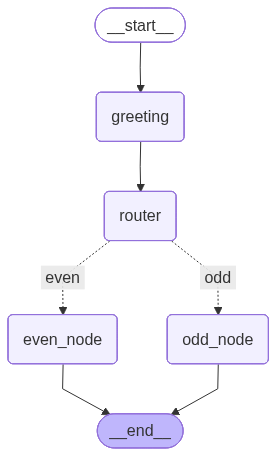

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
answer = app.invoke({"name" : "Abdelhak", "number" : 6 })
answer

TypeError: not all arguments converted during string formatting